Mirza Fathi Taufiqurrahman 5026231105

# Import Dependencies

In [ ]:
import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt')
from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# Define Document

In [ ]:
sentence2 = """Tokopedia dan TikTok Shop merilis data tren belanja masyarakat Indonesia selama kampanye Promo Guncang 9.9 2025. Beragam kategori produk mencatatkan nilai transaksi tertinggi di masing-masing platform.

Di Tokopedia, kategori dengan nilai transaksi terbesar yakni gawai dan elektronik, peralatan rumah tangga, kecantikan dan perawatan diri. Sementara, di TikTok Shop yakni makanan dan minuman, fesyen muslim, serta kecantikan dan perawatan diri.

Communications Senior Lead, Tokopedia and TikTok E-commerce Antonia Adega mengatakan, selain melalui #JualanNyaman, Tokopedia dan TikTok Shop juga memberdayakan pelaku usaha lokal lewat Kampanye Mega Sale di periode belanja paling ramai.  Seperti gajian dan tanggal kembar.

Adega menambahkan, sinergi Tokopedia dan TikTok Shop melalui Kampanye Mega Sale menjadi salah satu motor lonjakan pesanan 126 persen secara nasional, dan 93 persen di Yogya pada kuartal III 2025 dibandingkan tahun sebelumnya.

“Di balik pencapaian itu, pelaku usaha lokal termasuk UMKM batik ikut berperan sebagai jembatan yang menghubungkan potensi ekonomi lokal dengan peluang pasar digital,” kata Adega di Yogyakarta, Rabu (24/9/2025).

"Produk batik dengan transaksi tertinggi di Tokopedia adalah jaket, rok, dan outer batik wanita, sedangkan di TikTok Shop, batik couple, kebaya wanita, dan kemeja batik pria," lanjutnya.
Kampanye Mega Sale berikutnya, rinci Adega, akan dimulai dengan Gajian Sale pada 25 September 2025. Kemudian, berlanjut dengan kampanye tanggal kembar Promo Guncang 10.10 pada 6-10 Oktober 2025 di Tokopedia dan 1-10 Oktober di TikTok Shop.

“Pembeli dapat menikmati benefit seperti gratis ongkir tanpa batas, diskon hingga jutaan rupiah, flash sale dan masih banyak lagi. Kami berharap pelaku usaha lokal bisa memanfaatkan momen ini untuk memaksimalkan keuntungan,” sebut Adega.

Salah satu penjual batik di Tokopedia dan TikTok Shop, Mutiara Kurnia Dewi mengungkapkan Promo Guncang 9.9 2025 membantu meningkatkan pendapatan.
“Penjualan produk terbaru kami, Kebaya Janggan, berkat promo tersebut naik 80 persen,” kata pemilik Delova Wardrobe itu.

Pemilik Rianty Batik, Aditya Suryadinata menyatakan promo tanggal kembar di Tokopedia dan TikTok Shop bisa mendongkrak penjualan dua kali lipat."""

# Text Preprocessing

1.  **Sentence Tokenization**: Teks yang sudah didefinisikan (`sentence2`) dipecah menjadi kalimat-kalimat individual menggunakan `sent_tokenize` dari `nltk`.
2.  **Stop Word Removal**: Kata-kata tidak penting (stop words) dalam bahasa Indonesia dihapus dari setiap kalimat menggunakan `Sastrawi.StopWordRemover`. Ini bertujuan untuk meningkatkan relevansi kata-kata yang dianalisis.
3.  **TF-IDF Vectorization**: `TfidfVectorizer` dari `sklearn` digunakan untuk mengonversi setiap kalimat yang sudah dibersihkan menjadi representasi numerik. TF-IDF (Term Frequency-Inverse Document Frequency) memberikan bobot pada kata-kata berdasarkan seberapa sering muncul dalam suatu kalimat (TF) dan seberapa unik kata tersebut di seluruh dokumen (IDF). Semakin tinggi nilai TF-IDF, semakin penting kata tersebut dalam kalimat dan dokumen.

In [ ]:
import nltk
from nltk.tokenize import sent_tokenize

# Download the 'punkt_tab' data
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Sentence tokenization
sent_token2 = sent_tokenize(sentence2)
print(sent_token2)

['Tokopedia dan TikTok Shop merilis data tren belanja masyarakat Indonesia selama kampanye Promo Guncang 9.9 2025.', 'Beragam kategori produk mencatatkan nilai transaksi tertinggi di masing-masing platform.', 'Di Tokopedia, kategori dengan nilai transaksi terbesar yakni gawai dan elektronik, peralatan rumah tangga, kecantikan dan perawatan diri.', 'Sementara, di TikTok Shop yakni makanan dan minuman, fesyen muslim, serta kecantikan dan perawatan diri.', 'Communications Senior Lead, Tokopedia and TikTok E-commerce Antonia Adega mengatakan, selain melalui #JualanNyaman, Tokopedia dan TikTok Shop juga memberdayakan pelaku usaha lokal lewat Kampanye Mega Sale di periode belanja paling ramai.', 'Seperti gajian dan tanggal kembar.', 'Adega menambahkan, sinergi Tokopedia dan TikTok Shop melalui Kampanye Mega Sale menjadi salah satu motor lonjakan pesanan 126 persen secara nasional, dan 93 persen di Yogya pada kuartal III 2025 dibandingkan tahun sebelumnya.', '“Di balik pencapaian itu, pelaku 

In [ ]:
# Training TF-IDF Vectorizer on sentences---harusnya pakai SASTRAWI
vectorizer = TfidfVectorizer(stop_words='english')
features = vectorizer.fit_transform(sent_token2)

Selanjutnya, bagian **Calculate Sentence Score** akan menghitung skor rata-rata TF-IDF untuk setiap kalimat:

1.  **Inisialisasi**: Variabel `sent_index` dan `sent_scores` diinisialisasi untuk melacak indeks kalimat dan menyimpan skor.
2.  **Perhitungan Skor Rata-rata TF-IDF**: Untuk setiap kalimat dalam matriks fitur TF-IDF, jumlah semua skor TF-IDF dalam kalimat tersebut dihitung (`sent_score`). Kemudian, `sent_score` dibagi dengan jumlah kata unik dalam kalimat (`sent_length`) untuk mendapatkan skor rata-rata TF-IDF (`avg_score`).
3.  **Penyimpanan Skor**: Skor rata-rata TF-IDF setiap kalimat disimpan dalam list `sent_scores`.
4.  **Visualisasi**: Skor rata-rata TF-IDF divisualisasikan dalam bentuk histogram untuk melihat distribusi skor antar kalimat. Kalimat dengan skor lebih tinggi dianggap lebih penting.

**Hasilnya** adalah daftar kalimat dengan skor rata-rata TF-IDF masing-masing, serta visualisasi dalam bentuk bar chart.

In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 8.3 MB/s eta 0:00:00


In [ ]:
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Download the 'punkt' data if you haven't already
try:
    nltk.data.find('tokenizers/punkt/PY3/english.pickle')
except nltk.downloader.DownloadError:
    nltk.download('punkt')

# Sentence tokenization
sent_token2 = sent_tokenize(sentence2)
print("Tokenized sentences:")
for sent in sent_token2:
    print(sent)

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token2]
print("\nCleaned sentences (Indonesian stop words removed):")
for clean_sent in cleaned_sentences:
    print(clean_sent)

# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()  # Removed stop_words='english'
features = vectorizer.fit_transform(cleaned_sentences)

print("\nTF-IDF Feature Matrix (Sparse) on cleaned sentences:")
print(features)

print("\nShape of the Feature Matrix (Number of sentences, Number of unique words after Indonesian stop word removal):")
print(features.shape)

# To see the feature names (the words in the vocabulary after Indonesian stop word removal):
feature_names = vectorizer.get_feature_names_out()
print("\nFeature Names (Words in the vocabulary after Indonesian stop word removal):")
print(feature_names)

# To see the TF-IDF values for a specific cleaned sentence (e.g., the first):
if cleaned_sentences:
    first_cleaned_sentence_tfidf = features[0].toarray()
    print("\nTF-IDF values for the first cleaned sentence:")
    print(first_cleaned_sentence_tfidf)

    import pandas as pd
    def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
        """Returns a DataFrame of TF-IDF values for a given sentence."""
        sentence_tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
        tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf_values})
        tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
        return tfidf_df

    first_cleaned_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)
    print("\nTF-IDF values for the first cleaned sentence (sorted):")
    print(first_cleaned_sentence_tfidf_df)
else:
    print("\nNo cleaned sentences to process.")

Tokenized sentences:
Tokopedia dan TikTok Shop merilis data tren belanja masyarakat Indonesia selama kampanye Promo Guncang 9.9 2025.
Beragam kategori produk mencatatkan nilai transaksi tertinggi di masing-masing platform.
Di Tokopedia, kategori dengan nilai transaksi terbesar yakni gawai dan elektronik, peralatan rumah tangga, kecantikan dan perawatan diri.
Sementara, di TikTok Shop yakni makanan dan minuman, fesyen muslim, serta kecantikan dan perawatan diri.
Communications Senior Lead, Tokopedia and TikTok E-commerce Antonia Adega mengatakan, selain melalui #JualanNyaman, Tokopedia dan TikTok Shop juga memberdayakan pelaku usaha lokal lewat Kampanye Mega Sale di periode belanja paling ramai.
Seperti gajian dan tanggal kembar.
Adega menambahkan, sinergi Tokopedia dan TikTok Shop melalui Kampanye Mega Sale menjadi salah satu motor lonjakan pesanan 126 persen secara nasional, dan 93 persen di Yogya pada kuartal III 2025 dibandingkan tahun sebelumnya.
“Di balik pencapaian itu, pelaku us

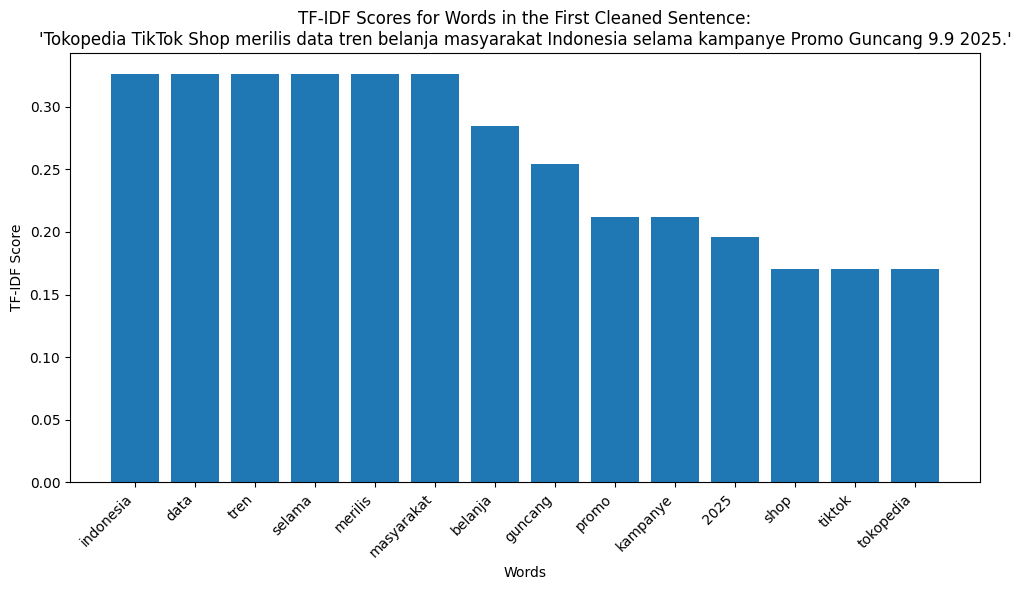

In [ ]:
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import matplotlib.pyplot as plt
import pandas as pd

# Download 'punkt' if needed
try:
    nltk.data.find('tokenizers/punkt/PY3/english.pickle')
except nltk.downloader.DownloadError:
    nltk.download('punkt')

# Sentence tokenization
sent_token2 = sent_tokenize(sentence2)

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token2]

# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)
feature_names = vectorizer.get_feature_names_out()

# Get TF-IDF scores for the first cleaned sentence
if cleaned_sentences:
    first_cleaned_sentence = cleaned_sentences[0]
    first_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)

    # Visualize the TF-IDF scores as a histogram
    plt.figure(figsize=(10, 6))
    plt.bar(first_sentence_tfidf_df['Feature'], first_sentence_tfidf_df['TF-IDF'])
    plt.xlabel("Words")
    plt.ylabel("TF-IDF Score")
    plt.title(f"TF-IDF Scores for Words in the First Cleaned Sentence:\n'{first_cleaned_sentence}'")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No cleaned sentences to visualize.")

# Calculate Sentence Score

Pada bagian **Define Threshold**, kita menentukan ambang batas (threshold) untuk memilih kalimat-kalimat yang paling penting:

1.  **Perhitungan Rata-rata Skor Keseluruhan**: Ambang batas dihitung sebagai rata-rata dari semua skor rata-rata TF-IDF setiap kalimat yang telah dihitung sebelumnya. Ini memberikan nilai tengah yang akan digunakan untuk memfilter kalimat.

**Hasilnya** adalah nilai tunggal yang merepresentasikan ambang batas (threshold) untuk pemilihan kalimat dalam ringkasan.

**List of Sentences:**
1. Tokopedia dan TikTok Shop merilis data tren belanja masyarakat Indonesia selama kampanye Promo Guncang 9.9 2025.
2. Beragam kategori produk mencatatkan nilai transaksi tertinggi di masing-masing platform.
3. Di Tokopedia, kategori dengan nilai transaksi terbesar yakni gawai dan elektronik, peralatan rumah tangga, kecantikan dan perawatan diri.
4. Sementara, di TikTok Shop yakni makanan dan minuman, fesyen muslim, serta kecantikan dan perawatan diri.
5. Communications Senior Lead, Tokopedia and TikTok E-commerce Antonia Adega mengatakan, selain melalui #JualanNyaman, Tokopedia dan TikTok Shop juga memberdayakan pelaku usaha lokal lewat Kampanye Mega Sale di periode belanja paling ramai.
6. Seperti gajian dan tanggal kembar.
7. Adega menambahkan, sinergi Tokopedia dan TikTok Shop melalui Kampanye Mega Sale menjadi salah satu motor lonjakan pesanan 126 persen secara nasional, dan 93 persen di Yogya pada kuartal III 2025 dibandingkan tahun sebelumnya.
8. “Di balik

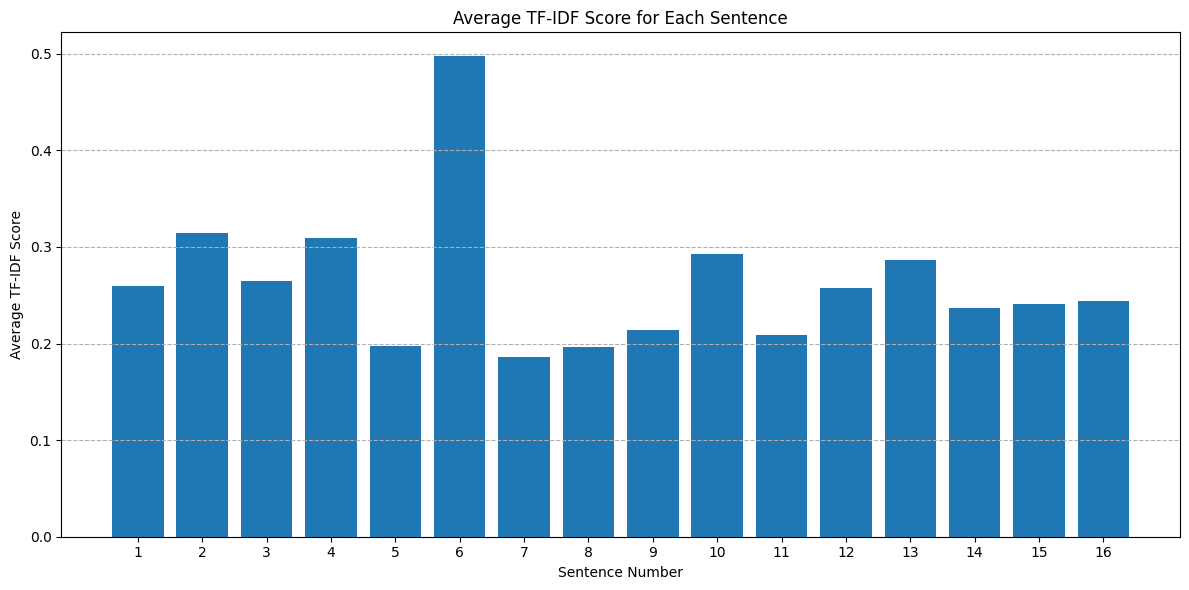


**Explanation of the Histogram :**
Imagine we've given each sentence in the news article a score based on the importance of the words it contains. This score is called the 'Average TF-IDF Score'.

The histogram above is like a bar chart that shows this score for each sentence:
- **The horizontal line (Sentence Number):** Each number on this line represents a different sentence in the article, starting from the first sentence (1) to the last.
- **The vertical bar for each sentence:** The height of each bar shows the 'Average TF-IDF Score' for that particular sentence.

**What does the height of the bar tell us?**
- **Taller bar:** A taller bar means the sentence contains words that are considered more important and unique within the entire article. These sentences likely carry more key information.
- **Shorter bar:** A shorter bar means the sentence contains words that are either less important or more common throughout the article. These sentences might be supporting details or less c

In [ ]:
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import matplotlib.pyplot as plt

# Download the 'punkt' data if needed
try:
    nltk.data.find('tokenizers/punkt/PY3/english.pickle')
except nltk.downloader.DownloadError:
    nltk.download('punkt')

# Sentence tokenization
sent_token2 = sent_tokenize(sentence2)

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token2]

# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)

# Variable initialization
sent_index = 0
sent_scores = []

# Calculate sentence TF-IDF score and list sentences
print("**List of Sentences:**")
for i, sent in enumerate(sent_token2):
    print(f"{i + 1}. {sent}")
print("\n-------------------------")

# Calculate average TF-IDF score for each sentence
print("\n**Average TF-IDF Score for Each Sentence:**")
for i in features:
    print(f"- Sentence {sent_index + 1}")
    sent_score = i.sum()
    sent_length = len(i.data)
    print("  Sum of TF-IDF scores:", sent_score)
    print("  Number of words:", sent_length)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    print("  Average TF-IDF score:", avg_score)
    sent_scores.append(avg_score)
    sent_index += 1
print("\n-------------------------")

print("\nList of average TF-IDF scores for each sentence:")
print(sent_scores)

# Visualize the average TF-IDF scores as a histogram
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(sent_scores) + 1), sent_scores)
plt.xlabel("Sentence Number")
plt.ylabel("Average TF-IDF Score")
plt.title("Average TF-IDF Score for Each Sentence")
plt.xticks(range(1, len(sent_scores) + 1))
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# Explanation:
print("\n**Explanation of the Histogram :**")
print("Imagine we've given each sentence in the news article a score based on the importance of the words it contains. This score is called the 'Average TF-IDF Score'.")
print("\nThe histogram above is like a bar chart that shows this score for each sentence:")
print("- **The horizontal line (Sentence Number):** Each number on this line represents a different sentence in the article, starting from the first sentence (1) to the last.")
print("- **The vertical bar for each sentence:** The height of each bar shows the 'Average TF-IDF Score' for that particular sentence.")
print("\n**What does the height of the bar tell us?**")
print("- **Taller bar:** A taller bar means the sentence contains words that are considered more important and unique within the entire article. These sentences likely carry more key information.")
print("- **Shorter bar:** A shorter bar means the sentence contains words that are either less important or more common throughout the article. These sentences might be supporting details or less central to the main topic.")
print("\nSo, by looking at this chart, you can quickly get a sense of which sentences in the article are likely to be the most informative based on the words they use.")

# Define Threshold

Terakhir, pada bagian **Get Sentences**, kalimat-kalimat yang akan membentuk ringkasan akhir dipilih berdasarkan ambang batas:

1.  **Pemilihan Kalimat**: Setiap kalimat dalam daftar `sent_scores` diperiksa. Jika skor rata-rata TF-IDF suatu kalimat lebih besar atau sama dengan ambang batas yang telah ditentukan, maka kalimat asli dari `sent_token` akan ditambahkan ke `final_summ`.
2.  **Pencetakan Ringkasan**: Kalimat-kalimat yang dipilih dicetak satu per satu, dan kemudian ringkasan akhir (`final_summ`) yang menggabungkan semua kalimat penting akan ditampilkan.

**Hasilnya** adalah ringkasan teks yang hanya berisi kalimat-kalimat yang dianggap paling penting berdasarkan skor TF-IDF mereka.

In [ ]:
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Download the 'punkt' data if needed
try:
    nltk.data.find('tokenizers/punkt/PY3/english.pickle')
except nltk.downloader.DownloadError:
    nltk.download('punkt')

# Sentence tokenization
sent_token2 = sent_tokenize(sentence2)

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token2]

# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)

# Variable initialization
sent_index = 0
sent_scores = []

# Calculate sentence TF-IDF score
for i in features:
    sent_score = i.sum()
    sent_length = len(i.data)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    sent_scores.append(avg_score)

# Calculate the average of all sentence scores (threshold)
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print("Threshold (Average of Sentence Scores):", threshold)

Threshold (Average of Sentence Scores): 0.2628208285076528


In [ ]:
import nltk
from nltk.tokenize import word_tokenize
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import math

# Download the 'punkt' data if needed
try:
    nltk.data.find('tokenizers/punkt/PY3/english.pickle')
except nltk.downloader.DownloadError:
    nltk.download('punkt')

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Initialize a list to store cleaned sentences
all_cleaned_sentences = []
for sentence in sentence2:
    cleaned_sentence = stopword_remover.remove(sentence)
    all_cleaned_sentences.append(cleaned_sentence)

# Function to calculate TF for a term in a document
def calculate_tf(term, document):
    words = word_tokenize(document.lower())
    return words.count(term) / len(words) if len(words) > 0 else 0

# Function to calculate IDF for a term across all documents
def calculate_idf(term, all_documents):
    num_documents_with_term = sum(1 for doc in all_documents if term.lower() in word_tokenize(doc.lower()))
    if num_documents_with_term > 0:
        return math.log(len(all_documents) / num_documents_with_term)
    else:
        return 0

tfidf_scores = {}
for i, sentence in enumerate(sentence2):
    cleaned_sentence = stopword_remover.remove(sentence)
    tf = calculate_tf("UMKM", cleaned_sentence)
    idf = calculate_idf("UMKM", all_cleaned_sentences)
    tfidf = tf * idf
    tfidf_scores[f"Sentence {i+1}"] = tfidf

print("TF-IDF Score for 'UMKM' in each cleaned sentence:")
for sentence_num, score in tfidf_scores.items():
    print(f"{sentence_num}: {score:.4f}")

overall_idf_umkm = calculate_idf("UMKM", all_cleaned_sentences)
print(f"\nOverall IDF for 'UMKM': {overall_idf_umkm:.4f}")

TF-IDF Score for 'investasi' in each cleaned sentence:
Sentence 1: 0.0827
Sentence 2: 0.0000
Sentence 3: 0.0359
Sentence 4: 0.0551
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.0533
Sentence 10: 0.0459
Sentence 11: 0.0000
Sentence 12: 0.0413
Sentence 13: 0.0000
Sentence 14: 0.0394
Sentence 15: 0.0000
Sentence 16: 0.0000

Overall IDF for 'investasi': 0.8267


In [ ]:
#threshold = sum(sent_scores)/len(sent_scores) # Average of Sentence Scores
#threshold

# Get Sentences

In [ ]:
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Download the 'punkt' data if needed
try:
    nltk.data.find('tokenizers/punkt/PY3/english.pickle')
except nltk.downloader.DownloadError:
    nltk.download('punkt')


# Sentence tokenization (using the original sentence2)
sent_token = sent_tokenize(sentence2)

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token]

# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)

# Variable initialization
sent_index = 0
sent_scores = []

# Calculate average TF-IDF score for each sentence
for i in features:
    sent_score = i.sum()
    sent_length = len(i.data)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    sent_scores.append(avg_score)

# Calculate the average of all sentence scores (threshold)
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print("Threshold (Average of Sentence Scores):", threshold)

# Final summary initialization
final_summ = ""

# Get summary sentences
print("\n**Summary Sentences (above or equal to the threshold):**")
for index, data in enumerate(sent_scores):
    if data >= threshold:
        final_summ = final_summ + " " + sent_token[index]
        print(f"- {sent_token[index]}")

print("\n**Final Summary:**")
print(final_summ.strip())

Threshold (Average of Sentence Scores): 0.2628208285076528

**Summary Sentences (above or equal to the threshold):**
- Beragam kategori produk mencatatkan nilai transaksi tertinggi di masing-masing platform.
- Di Tokopedia, kategori dengan nilai transaksi terbesar yakni gawai dan elektronik, peralatan rumah tangga, kecantikan dan perawatan diri.
- Sementara, di TikTok Shop yakni makanan dan minuman, fesyen muslim, serta kecantikan dan perawatan diri.
- Seperti gajian dan tanggal kembar.
- Kampanye Mega Sale berikutnya, rinci Adega, akan dimulai dengan Gajian Sale pada 25 September 2025.
- Kami berharap pelaku usaha lokal bisa memanfaatkan momen ini untuk memaksimalkan keuntungan,” sebut Adega.

**Final Summary:**
Beragam kategori produk mencatatkan nilai transaksi tertinggi di masing-masing platform. Di Tokopedia, kategori dengan nilai transaksi terbesar yakni gawai dan elektronik, peralatan rumah tangga, kecantikan dan perawatan diri. Sementara, di TikTok Shop yakni makanan dan minuma

In [ ]:
import nltk
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import math

# Download the 'punkt' data if needed
try:
    nltk.data.find('tokenizers/punkt/PY3/english.pickle')
except nltk.downloader.DownloadError:
    nltk.download('punkt')

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Function to calculate TF for a term in a document
def calculate_tf(term, document):
    words = word_tokenize(document.lower())
    return words.count(term) / len(words) if len(words) > 0 else 0

# Function to calculate IDF for a term across all documents
def calculate_idf(term, all_documents):
    num_documents_with_term = sum(1 for doc in all_documents if term.lower() in word_tokenize(doc.lower()))
    if num_documents_with_term > 0:
        return math.log(len(all_documents) / num_documents_with_term)
    else:
        return 0

tfidf_scores = {}
all_cleaned_sentences = []

for i, sentence in enumerate(sentence2):
    cleaned_sentence = stopword_remover.remove(sentence2)
    all_cleaned_sentences.append(cleaned_sentence)
    tf = calculate_tf("UMKM", cleaned_sentence)
    idf = calculate_idf("UMKM", all_cleaned_sentences)
    tfidf = tf * idf
    tfidf_scores[f"Sentence {i+1}"] = tfidf

print("TF-IDF Score for 'UMKM' in each sentence:")
for sentence_num, score in tfidf_scores.items():
    print(f"{sentence_num}: {score:.4f}")

overall_idf_umkm = calculate_idf("UMKM", all_cleaned_sentences)
print(f"\nOverall IDF for 'umkm': {overall_idf_umkm:.4f}")

# You can also use scikit-learn's TfidfVectorizer for a more direct approach:
vectorizer = TfidfVectorizer(stop_words=factory.get_stop_words())
tfidf_matrix = vectorizer.fit_transform(sentence2)
feature_names = vectorizer.get_feature_names_out()

try:
    umkm_index = list(feature_names).index("UMKM")
    print("\nTF-IDF Score for 'umkm' using TfidfVectorizer:")
    for i, sentence in enumerate(sentence2):
        tfidf = tfidf_matrix[i, umkm_index]
        print(f"Sentence {i+1}: {tfidf:.4f}")
except ValueError:
    print("\n'umkm' not found in the vocabulary after stop word removal by TfidfVectorizer.")

TF-IDF Score for 'investasi' in each sentence:
Sentence 1: 0.0000
Sentence 2: 0.0000
Sentence 3: 0.0176
Sentence 4: 0.0192
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.0523
Sentence 10: 0.0385
Sentence 11: 0.0000
Sentence 12: 0.0347
Sentence 13: 0.0000
Sentence 14: 0.0330
Sentence 15: 0.0000
Sentence 16: 0.0000

Overall IDF for 'investasi': 0.8267

TF-IDF Score for 'investasi' using TfidfVectorizer:
Sentence 1: 0.3174
Sentence 2: 0.0000
Sentence 3: 0.1420
Sentence 4: 0.1765
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.2128
Sentence 10: 0.1676
Sentence 11: 0.0000
Sentence 12: 0.1502
Sentence 13: 0.0000
Sentence 14: 0.1639
Sentence 15: 0.0000
Sentence 16: 0.0000


In [ ]:
final_summ

' Beragam kategori produk mencatatkan nilai transaksi tertinggi di masing-masing platform. Di Tokopedia, kategori dengan nilai transaksi terbesar yakni gawai dan elektronik, peralatan rumah tangga, kecantikan dan perawatan diri. Sementara, di TikTok Shop yakni makanan dan minuman, fesyen muslim, serta kecantikan dan perawatan diri. Seperti gajian dan tanggal kembar. Kampanye Mega Sale berikutnya, rinci Adega, akan dimulai dengan Gajian Sale pada 25 September 2025. Kami berharap pelaku usaha lokal bisa memanfaatkan momen ini untuk memaksimalkan keuntungan,” sebut Adega.'

In [ ]:
# Final summary initialization
final_summ = ""

# Get summary sentences
for index, data in enumerate(sent_scores) :
  if (data >= (threshold)) :
    final_summ = final_summ + " " + sent_token[index]
    print("- ", sent_token[index])

-  Beragam kategori produk mencatatkan nilai transaksi tertinggi di masing-masing platform.
-  Di Tokopedia, kategori dengan nilai transaksi terbesar yakni gawai dan elektronik, peralatan rumah tangga, kecantikan dan perawatan diri.
-  Sementara, di TikTok Shop yakni makanan dan minuman, fesyen muslim, serta kecantikan dan perawatan diri.
-  Seperti gajian dan tanggal kembar.
-  Kampanye Mega Sale berikutnya, rinci Adega, akan dimulai dengan Gajian Sale pada 25 September 2025.
-  Kami berharap pelaku usaha lokal bisa memanfaatkan momen ini untuk memaksimalkan keuntungan,” sebut Adega.


# Summarization Result

In [ ]:
final_summ

' Beragam kategori produk mencatatkan nilai transaksi tertinggi di masing-masing platform. Di Tokopedia, kategori dengan nilai transaksi terbesar yakni gawai dan elektronik, peralatan rumah tangga, kecantikan dan perawatan diri. Sementara, di TikTok Shop yakni makanan dan minuman, fesyen muslim, serta kecantikan dan perawatan diri. Seperti gajian dan tanggal kembar. Kampanye Mega Sale berikutnya, rinci Adega, akan dimulai dengan Gajian Sale pada 25 September 2025. Kami berharap pelaku usaha lokal bisa memanfaatkan momen ini untuk memaksimalkan keuntungan,” sebut Adega.'